In [49]:
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB



from hjelpefunskjoner import is_garbage
from hjelpefunskjoner import map_sentiment


path = "data/reviews.csv"
df = pd.read_csv(path)
df.head(10)

,review_id,rating,review_text,review_date,helpful
0,981e465b-d3ba-4632-9c60-25051efac38a,5,It's good,11/22/2025 1:19,0
1,964d3555-9429-4c20-8127-ce3c71ce9273,5,WhatsApp not working well always shows offline...,11/24/2025 20:03,0
2,6c28859f-1554-4ca1-9aa8-9d66f204be0a,5,"Oppo not corresponding, share with me the offi...",11/25/2025 6:26,0
3,a7efafc3-5871-4020-a398-9cc12cb4072a,5,"Excellent app, great communication super conne...",11/25/2025 18:09,0
4,de142b31-a5ad-446f-b7c8-51b264728478,4,simply the ɓest for chat and calls.i love it,11/24/2025 1:10,1
5,8b0ffc3b-d7d0-4198-8ce0-763674359246,5,good. but i need WhatsApp premium features,11/26/2025 16:42,0
6,XCdQN9L5-PsBJ-ftUV-Ov6H-Na1v3f0JxTLs,4,learning learning learning learning learning l...,25/11/2025 06:54,1
7,18294fa1-0410-4476-970f-33f188b0abfe,5,Awesome. I just need it to download and install,11/22/2025 20:27,0
8,c9fd6209-d8ed-482e-9b03-68cc2100fed0,5,very nice app thnx so much,11/22/2025 15:53,0
9,75b5068d-6b9b-4aa6-a069-abdb6bfc6388,5,Really really apriacite 100/,11/26/2025 17:06,0


In [50]:
df.info()

df["rating"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6210 entries, 0 to 6209
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    6210 non-null   object
 1   rating       6210 non-null   int64 
 2   review_text  6210 non-null   object
 3   review_date  6210 non-null   object
 4   helpful      6210 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 242.7+ KB


rating
5    3021
1    1582
4     632
3     508
2     467
Name: count, dtype: int64

In [51]:
df.describe()

,rating,helpful
count,6210.000000,6210.000000
mean,3.490016,43.463607
std,1.703590,3161.807086
min,1.000000,0.000000
25%,1.000000,0.000000
50%,4.000000,0.000000
75%,5.000000,0.000000
max,5.000000,248962.000000


In [52]:
df.isna().sum()

review_id      0
rating         0
review_text    0
review_date    0
helpful        0
dtype: int64

Text(0.5, 1.0, 'Distribution of Review Lengths')

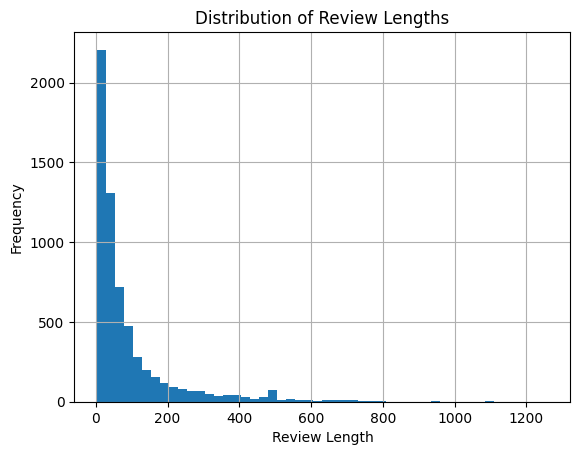

In [53]:


df['review_text'].str.len().hist(bins=50)

plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.title('Distribution of Review Lengths')

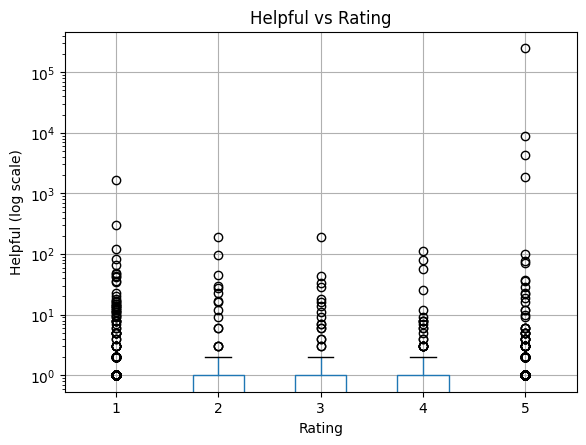

In [54]:
df.boxplot(column="helpful", by="rating")
plt.yscale("log")

plt.title("Helpful vs Rating")
plt.suptitle("")
plt.xlabel("Rating")
plt.ylabel("Helpful (log scale)")
plt.show()

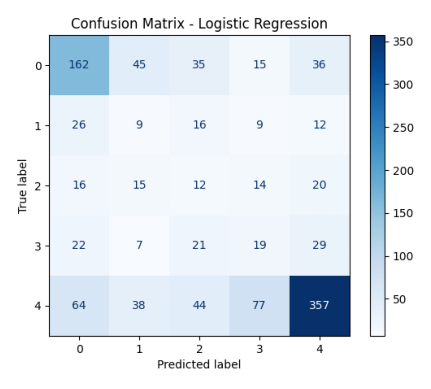

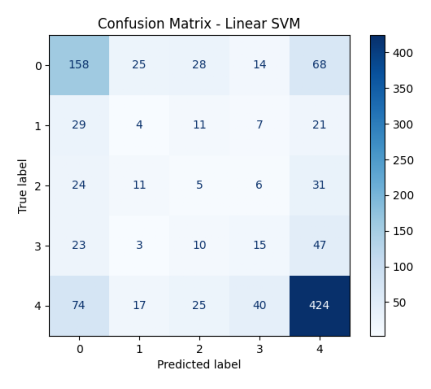

In [55]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("figures/figur 1.png")
img2 = mpimg.imread("figures/figur 2.png")

plt.imshow(img)
plt.axis("off")
plt.show()

plt.imshow(img2)
plt.axis("off")
plt.show()

Vi kjørte første analyse på to modeller, Logistic Regression og Linear SVM. Grunnlaget var å teste det vi så på grafen over rating/helpful. På grafen så vi at helpful var lav på rating 2-4. Dette kan tilsi mye likt språk og ikke noe konkret. Eksempel rating 1 = not good, rating 5 = good, mens rating 2/3 = some things good, some things bad. Før vi eventuelt endret rating 1-5 til å være 0, 1, 2 (negativ, nøytral, positiv) ville vi analysere decisionmatrix. Som vi ser fra den sliter modellene med å skille rating 2, 3 og 4 fra hverandre, vi brukte class_weight=balance i modellene for å se dette tydelig. Vi endrer derfor ratingsystemet til å bli: rating 1-2 = negativ(0), rating 3 = nøytral(1), rating 4-5 = positiv (2) i vår pipeline

In [56]:
# Fjerner kolonner som ikke har noen påvirkning på vurderingen til brukere
df.drop(columns=["review_id", "review_date", "helpful"], inplace=True)
df.head(10)

,rating,review_text
0,5,It's good
1,5,WhatsApp not working well always shows offline...
2,5,"Oppo not corresponding, share with me the offi..."
3,5,"Excellent app, great communication super conne..."
4,4,simply the ɓest for chat and calls.i love it
5,5,good. but i need WhatsApp premium features
6,4,learning learning learning learning learning l...
7,5,Awesome. I just need it to download and install
8,5,very nice app thnx so much
9,5,Really really apriacite 100/


In [57]:
# Ser på fordelingen av ratings
rating_counts = df["rating"].value_counts().sort_index()
display(rating_counts)
display((rating_counts / len(df)).round(3))

rating
1    1582
2     467
3     508
4     632
5    3021
Name: count, dtype: int64

rating
1    0.255
2    0.075
3    0.082
4    0.102
5    0.486
Name: count, dtype: float64

Vi ser at rating 2-4 står for ganske lite av den totale ratingen, 1 har greit antall (rundt 25 %) og rating 5 står for nesten 50 % av alle ratings. Det må derfor vurders å gjøre oversampling/undersampling. 

In [58]:
text = df["review_text"].astype(str)

# Antall ord i hver anmeldelse
df["n_words"] = text.str.split().str.len()

# Beskrivende statistikk for antall ord
display(df[["n_words"]].describe())

# Se noen veldig korte/lange
display(df.sort_values("n_words").head(5)[["rating","review_text","n_words"]])
display(df.sort_values("n_words", ascending=False).head(5)[["rating","review_text","n_words"]])

# Mean per rating
display(
    df.groupby("rating")[["n_words"]].mean()
)

,n_words
count,6210.000000
mean,15.456200
std,19.791963
min,1.000000
25%,4.000000
50%,7.000000
75%,18.750000
max,105.000000


,rating,review_text,n_words
1561,5,easy-to-use,1
1587,4,11111111111111111111111111111,1
3600,1,chalo,1
3628,4,sssssssssssssssssss,1
53,5,5EDeqSdCqcmKFz3ewUgZkUKWdc72plozQCTGVGO4mcz09E...,1


,rating,review_text,n_words
4022,1,worst app ever. app asks me to register whatsa...,105
2280,3,I'm a WhatsApp heavy user .. and what I can te...,105
4077,5,my name is Mzamane Nkuriso i was born on Satur...,104
584,5,it is boring because it doesn't have a theme a...,103
5421,3,I love this app..it is good mostly also on the...,102


,n_words
rating,
1,20.642857
2,24.066381
3,21.293307
4,19.582278
5,9.564383


Vi legger merke til to ting:   
    1. Det er flere reviews-tekst uten betydning der teksten ikke har noe korrelasjon med hvilken score det eventuelt kan være. 
    2. Det er en korrelasjon mellom korte reviews og rating 5.
Siden den er en sterkt korrelasjon mellom få ord i reviewtekst og rating 5 så kan vi vurdere å bruke n_words som en feature

Vi lager en funksjon for å rydde opp i dataen. Denne funksjonen hjalp ChatGPT til med. 

In [59]:

df = df[~df["review_text"].apply(is_garbage)]

Vi kjører funksjonen på alle rader i datasette vært under kolonnen review_tekst. 

In [60]:
display(df.sort_values("n_words").head(5)[["rating","review_text","n_words"]])

,rating,review_text,n_words
4201,5,Great,1
2751,5,Great,1
2405,5,Chat,1
4369,5,clear,1
4370,5,Perfect,1


In [61]:
display(df["rating"].value_counts(normalize=True).sort_index())

rating
1    0.261786
2    0.064286
3    0.068571
4    0.087500
5    0.517857
Name: proportion, dtype: float64

Vi ser at review med score 5 er veldig mange av, mens 2-4 er veldig få av. 1 er greit balansert. Dette kan gjøre det vanskelig for modellen å lære å predikere score 2-4. Vi tester med to baseline modeller og analyserer resultatet.

In [62]:
#map_sentiment(df["rating"])

In [63]:


X = df[["review_text"]]
y = df["rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [64]:
display(y_train.value_counts().sort_index())

rating
1    1173
2     288
3     307
4     392
5    2320
Name: count, dtype: int64

In [65]:
stopwords = list(ENGLISH_STOP_WORDS)
stopwords.remove("not")
stopwords.remove("no")
stopwords.remove("very")
stopwords.remove("never")
stopwords.remove("but")
stopwords.remove("too")

In [66]:
def TF_IDF_vektorer():
    preprocessor_Tfid = ColumnTransformer(
        transformers=[
            ("text", TfidfVectorizer(
                ngram_range=(1,2),
                min_df=5,
                max_df=0.8,
                stop_words= None,
            ), "review_text"),
        ]
    )
    return preprocessor_Tfid

def Count_vektorer():
    preprocessor_Count = ColumnTransformer(
        transformers=[
            ("text", CountVectorizer(
                ngram_range=(1,2),
                min_df=5,
                max_df=0.8,
                stop_words= None,
            ), "review_text")
        ]
    )
    return preprocessor_Count



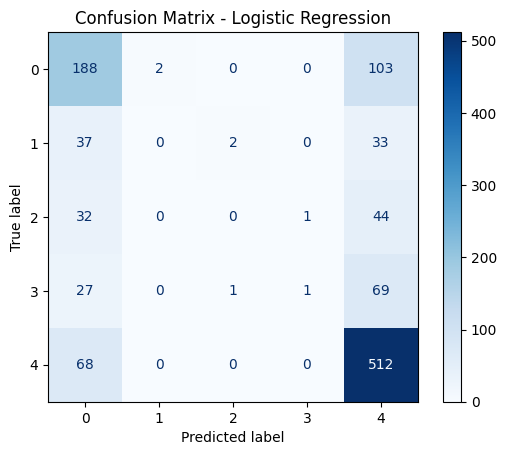

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    #"Linear SVM": LinearSVC(),
    #"Naive Bayes": MultinomialNB()
    #
 }
preprocessor = None
results_list = []


for name, classifier in models.items():
    if name == "Logistic Regression" or name == "Linear SVM":
        preprocessor = TF_IDF_vektorer()
    elif name == "Naive Bayes":
        preprocessor = Count_vektorer()

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    f1Score_avg = classification_report(y_test, y_pred, output_dict=True)
    macro_f1 = f1Score_avg["macro avg"]["f1-score"]
    confusionMatrix = confusion_matrix(y_test, y_pred)

    results_list.append({
        "model": name,
        "macro_f1": macro_f1,
        "vectorizer": "TF-IDF" if name in ["Logistic Regression", "Linear SVM"] else "Count",
        "Stopwords": "Yes"
    })
    

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by="Macro F1", ascending=False)    
    
    
    #confusionMatrix = confusion_matrix(y_test, y_pred)
    #disp = ConfusionMatrixDisplay(confusion_matrix=confusionMatrix)
    #disp.plot(cmap="Blues")
    #plt.title(f"Confusion Matrix - {name}")
    #plt.show()


In [68]:
results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = y_pred

print(results[(results["actual"] == 1) & (results["predicted"] == 5)].head(50))

                                            review_text  actual  predicted
1091                                         Not useful       1          5
4489  you need to update this app make it more HD wh...       1          5
1149  need to track people that are doing inappropri...       1          5
17    i can't open my whatsapp whenever i open it.. ...       1          5
434   honey skill produce make this as evaluate tunn...       1          5
1718                        I can make my friends happy       1          5
4987                     I need to update my what's app       1          5
2392  hi WhatsApp teams my WhatsApp account band ple...       1          5
3769                                           WhatsApp       1          5
4158                            i cannot login whatsapp       1          5
3292       all about this app not function like whasapp       1          5
4415  this app is very good please don't change afte...       1          5
3206  we need same featur